# Importing module


In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  # to suppress sklearn warnings
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


In [2]:
file = "C:/Users/USER-PC/QSAR_Code/Eye Irritation/dataset/Eye_irritation.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

Failed to patch pandas - unable to change molecule rendering


(1828, 7)
(1828, 7)


Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Mol'],
      dtype='object')

In [4]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [5]:
moldf.head(1)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Mol
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x00000298228...


In [6]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Mol,RowID
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x00000298228...,0
1459,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.030244522406833688, 0.6355786907582167, 0.7...",2134,COP(=S)(OC)Oc1cc(Cl)c(I)cc1Cl,<rdkit.Chem.rdchem.Mol object at 0x00000298259...,1459
1458,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.951268316448439, -1.0499930471440644, -1.0...",1602,CO[P+](=O)OC,<rdkit.Chem.rdchem.Mol object at 0x00000298259...,1458
1456,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2407228208736663, 0.9356286431485418, 1.01...",2173,C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1,<rdkit.Chem.rdchem.Mol object at 0x00000298259...,1456
749,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5299624423347523, -0.6051841368109854, -0....",1513,CC(C)=CCCC(C)CCO,<rdkit.Chem.rdchem.Mol object at 0x00000298239...,749
...,...,...,...,...,...,...,...,...
1405,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4717216426613299, 0.03353380012611423, 0.0...",1219,CCC(C)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x00000298259...,1405
1406,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.609765268089576, -0.020928241732461463, 0....",1302,CCc1cccc(C)c1,<rdkit.Chem.rdchem.Mol object at 0x00000298259...,1406
794,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.07080547351670781, 0.37284411323478117, 0....",1684,C=CCOc1ccc(CC(=O)O)cc1Cl,<rdkit.Chem.rdchem.Mol object at 0x00000298239...,794
795,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7089222229505214, 0.07259427279942421, -0....",1992,O=C1OCC(CO)O1,<rdkit.Chem.rdchem.Mol object at 0x00000298239...,795


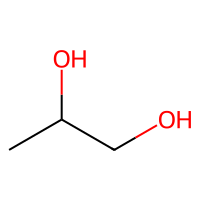

CC(O)CO


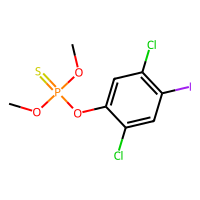

COP(=S)(OC)Oc1cc(Cl)c(I)cc1Cl


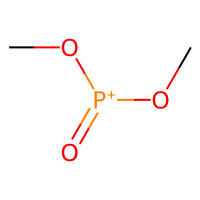

CO[P+](=O)OC


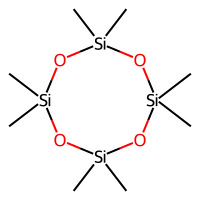

C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1


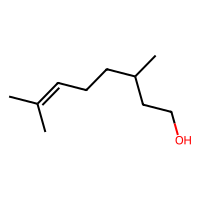

CC(C)=CCCC(C)CCO


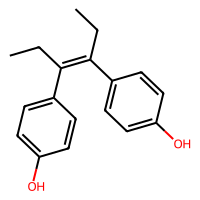

CCC(=C(CC)c1ccc(O)cc1)c1ccc(O)cc1


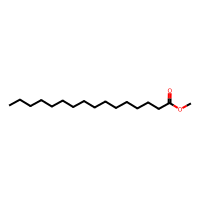

CCCCCCCCCCCCCCCC(=O)OC


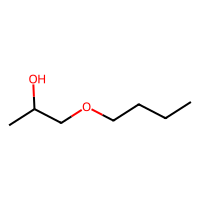

CCCCOCC(C)O


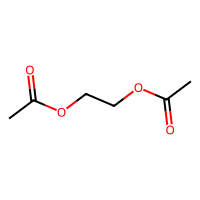

CC(=O)OCCOC(C)=O


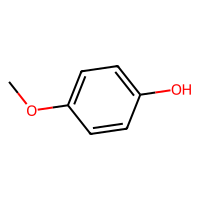

COc1ccc(O)cc1


In [7]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(df, num_mols):
    for _, row in df.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


In [8]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 12 01:46:05 PM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 12 01:46:05 PM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 12 01:46:05 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


# Descriptor 

In [9]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [10]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

  1%|▏         | 27/1828 [00:03<02:11, 13.69it/s] 

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  8%|▊         | 155/1828 [00:04<00:21, 77.26it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 16%|█▋        | 299/1828 [00:06<00:19, 77.86it/s] 

...

 80%|████████  | 1463/1828 [00:21<00:03, 92.91it/s] 

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 93%|█████████▎| 1696/1828 [00:23<00:01, 87.24it/s] 

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 1828/1828 [00:25<00:00, 72.81it/s] 


In [11]:
from fancyimpute import KNN
import pandas as pd
import numpy as np

df_numeric = df.select_dtypes(include=[float])  
df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/1828 with 0 missing, elapsed time: 5.289
Imputing row 101/1828 with 0 missing, elapsed time: 5.290
Imputing row 201/1828 with 0 missing, elapsed time: 5.290
Imputing row 301/1828 with 0 missing, elapsed time: 5.291
Imputing row 401/1828 with 0 missing, elapsed time: 5.291
Imputing row 501/1828 with 0 missing, elapsed time: 5.292
Imputing row 601/1828 with 0 missing, elapsed time: 5.292
Imputing row 701/1828 with 0 missing, elapsed time: 5.293
Imputing row 801/1828 with 0 missing, elapsed time: 5.293
Imputing row 901/1828 with 0 missing, elapsed time: 5.294
Imputing row 1001/1828 with 0 missing, elapsed time: 5.294
Imputing row 1101/1828 with 0 missing, elapsed time: 5.295
Imputing row 1201/1828 with 0 missing, elapsed time: 5.295
Imputing row 1301/1828 with 0 missing, elapsed time: 5.295
Imputing row 1401/1828 with 0 missing, elapsed time: 5.296
Imputing row 1501/1828 with 0 missing, elapsed time: 5.296
Imputing row 1601/1828 with 0 missing, elapsed time: 5.297
Imputing 

In [12]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [13]:
print(x.shape)

(1828, 691)


In [14]:
moldf

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Mol,RowID
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0815002093053054, -1.3672376514550153, -1....",1608,CC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x000001FFF0B...,0
1459,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.023992005618006296, 0.6240395124176665, 0.6...",2134,COP(=S)(OC)Oc1cc(Cl)c(I)cc1Cl,<rdkit.Chem.rdchem.Mol object at 0x000001FFF3C...,1459
1458,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9481570724383582, -1.0473741388115327, -1....",1602,CO[P+](=O)OC,<rdkit.Chem.rdchem.Mol object at 0x000001FFF3C...,1458
1456,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.24439027378319342, 0.9215691726503388, 0.9...",2173,C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1,<rdkit.Chem.rdchem.Mol object at 0x000001FFF3C...,1456
749,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5308705114423441, -0.6063014343982839, -0....",1513,CC(C)=CCCC(C)CCO,<rdkit.Chem.rdchem.Mol object at 0x000001FFF2C...,749
...,...,...,...,...,...,...,...,...
808,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.545843065585402, 0.2281311323305266, 0.282...",904,Nc1ccccc1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x000001FFF2C...,808
807,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.1416153043760298, -2.241044392035084, -2.2...",12,CCCO,<rdkit.Chem.rdchem.Mol object at 0x000001FFF2C...,807
804,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.07086669525158208, 1.6056805861488372, 1.17...",335,CC(CO)COC1CC2CCC1(C)C2(C)C,<rdkit.Chem.rdchem.Mol object at 0x000001FFF2C...,804
815,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.35324222778248315, 1.2480658024314184, 1.33...",851,O=C1c2cccc(O)c2C(=O)c2c(O)cccc21,<rdkit.Chem.rdchem.Mol object at 0x000001FFF2C...,815


In [15]:
moldf.keys()

Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Mol', 'RowID'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



# Remove duplicate columns
data = data.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Eye Irritation/dataset/train_set_eye_irritation_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Eye Irritation/dataset/tes_set_eye_irritation_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


In [ ]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Eye Irritation/dataset/train_set_eye_irritation_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Eye Irritation/dataset/tes_set_eye_irritation_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())
